In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import sys
sys.path.append('..')

In [4]:
from src.preprocessing import load_and_clean, engineer_features
df = load_and_clean('../data/bank_churn.csv')
df = engineer_features(df)

In [5]:
cluster_features = ['Age', 'Balance', 'CreditScore', 'Tenure', 'IsActiveMember', 'balance_salary_ratio']
X_cluster = df[cluster_features].copy()

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [8]:
#Elbow method to test the value of K from 2 to 10
inertias = []
for k in range(2,11):
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

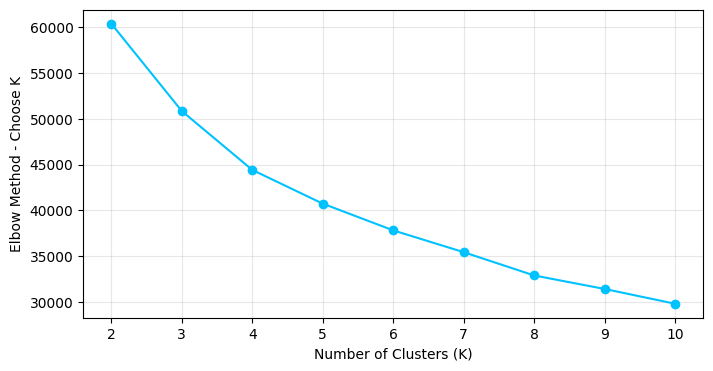

In [9]:
plt.figure(figsize = (8,4))
plt.plot(range(2,11), inertias, 'o-' , color = '#00C2FF')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Elbow Method - Choose K')
plt.grid(True, alpha = 0.3)
plt.show()

In [10]:
#applying k means with 4 clusters
kmeans = KMeans (n_clusters = 4, random_state = 42, n_init = 10)
df['segment'] = kmeans.fit_predict(X_scaled)

segment_profile = df.groupby('segment')[cluster_features + ['Exited']].mean()
print(segment_profile.round(2))

print('\nChurn rate per segment: ')
print(df.groupby('segment')['Exited'].mean().round(3))

           Age    Balance  CreditScore  Tenure  NumOfProducts  IsActiveMember  \
segment                                                                         
0        38.44      12.95       649.45    5.07           1.79            0.52   
1        38.52  120482.51       648.06    5.11           1.39            0.00   
2        39.84  119228.37       654.04    4.86           1.38            1.00   
3        45.00  122917.71       709.00    4.00           1.00            1.00   

         balance_salary_ratio  is_zero_balance  Exited  
segment                                                 
0                        0.00              1.0    0.14  
1                        4.94              0.0    0.32  
2                        3.90              0.0    0.17  
3                     9770.88              0.0    1.00  

Churn rate per segment: 
segment
0    0.138
1    0.316
2    0.169
3    1.000
Name: Exited, dtype: float64
